In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
%matplotlib inline

In [6]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/2. Encoding/Frequency Encoding.csv")

In [7]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Console Freq,Genre Freq
0,Grand Theft Auto V,9.40000,20.33,6.37,0.99,9.85,3.12,2013,93,22,1348,2839
1,Grand Theft Auto V,9.70000,19.39,6.06,0.60,9.71,3.02,2014,93,22,908,2839
2,Grand Theft Auto: Vice City,9.60000,16.15,8.41,0.47,5.49,1.78,2002,93,22,2125,2839
3,Grand Theft Auto V,7.10189,15.87,9.06,0.06,5.33,1.42,2013,93,22,1302,2839
4,Call of Duty: Black Ops 3,8.10000,15.09,6.18,0.41,6.05,2.44,2015,1044,56,908,1485


In [8]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
EU Sales                float64
Other Sales             float64
Release Year              int64
Publisher Freq            int64
Developer Freq            int64
Console Freq              int64
Genre Freq                int64
dtype: object

In [9]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2015 else 0)

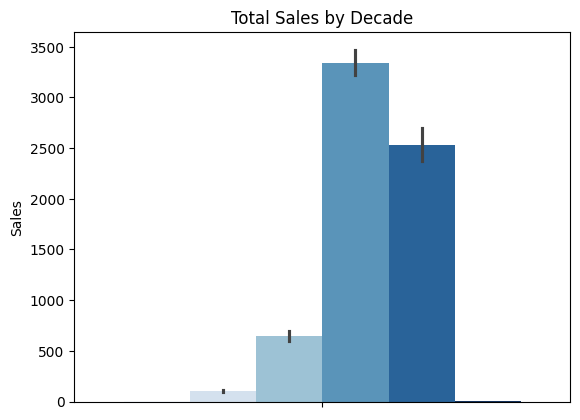

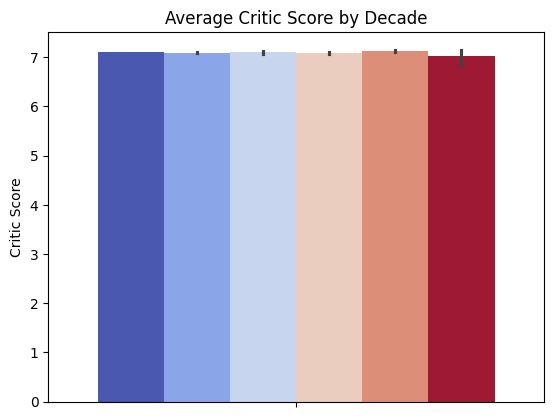

In [10]:
# Check sales trends across decades

sns.barplot(hue="Decade", y="Sales", data=df, estimator="sum", palette="Blues", legend=False)
plt.title("Total Sales by Decade")
plt.show()

sns.barplot(hue="Decade", y="Critic Score", data=df, estimator="mean", palette="coolwarm", legend=False)
plt.title("Average Critic Score by Decade")
plt.show()

In [11]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Console Freq,Genre Freq,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent
0,Grand Theft Auto V,9.40000,20.33,6.37,0.99,9.85,3.12,2013,93,22,1348,2839,2010,0.313330,0.484506,0.048697,0.153468,0
1,Grand Theft Auto V,9.70000,19.39,6.06,0.60,9.71,3.02,2014,93,22,908,2839,2010,0.312532,0.500774,0.030944,0.155750,0
2,Grand Theft Auto: Vice City,9.60000,16.15,8.41,0.47,5.49,1.78,2002,93,22,2125,2839,2000,0.520743,0.339938,0.029102,0.110217,0
3,Grand Theft Auto V,7.10189,15.87,9.06,0.06,5.33,1.42,2013,93,22,1302,2839,2010,0.570888,0.335854,0.003781,0.089477,0
4,Call of Duty: Black Ops 3,8.10000,15.09,6.18,0.41,6.05,2.44,2015,1044,56,908,1485,2010,0.409543,0.400928,0.027170,0.161696,1


In [12]:
# Bins and labels
bins = [0, 3, 7, 10]          # cut points
labels = ["Low", "Medium", "High"] # category names

# New Game Quality column 
df["Game Quality"] = pd.cut(df["Critic Score"], bins=bins, labels=labels, include_lowest=True)

# Label Encode categories as integers
encoding_map = {"Low": 0, "Medium": 1, "High": 2}
df["Game Quality Encoded"] = df["Game Quality"].map(encoding_map)

# check
print(df[["Critic Score", "Game Quality", "Game Quality Encoded"]].head(20))

    Critic Score Game Quality Game Quality Encoded
0        9.40000         High                    2
1        9.70000         High                    2
2        9.60000         High                    2
3        7.10189         High                    2
4        8.10000         High                    2
5        8.70000         High                    2
6        8.80000         High                    2
7        9.80000         High                    2
8        8.40000         High                    2
9        8.00000         High                    2
10       9.50000         High                    2
11       8.10000         High                    2
12       8.80000         High                    2
13       9.50000         High                    2
14       8.70000         High                    2
15       8.30000         High                    2
16      10.00000         High                    2
17       8.90000         High                    2
18       9.50000         High  

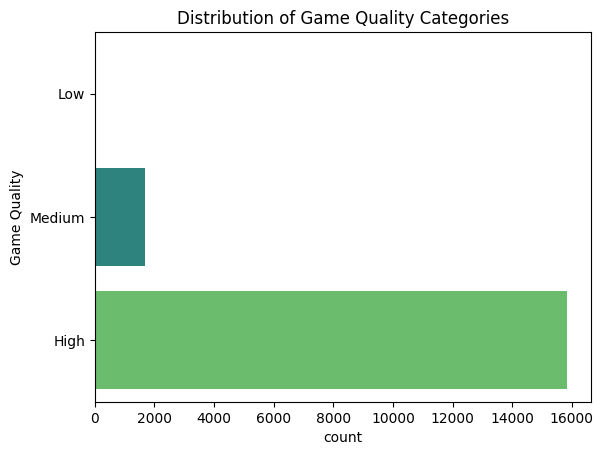

In [13]:
# Distribution of Game Quality

sns.countplot(hue="Game Quality", y="Game Quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Game Quality Categories")
plt.show()

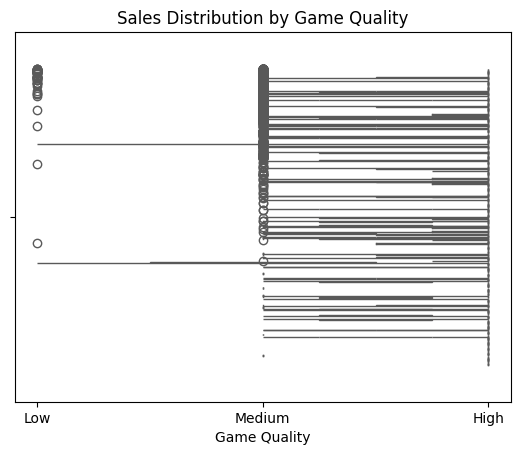

In [14]:
sns.boxplot(x="Game Quality", hue="Sales", data=df, palette="Set2", legend=False)
plt.title("Sales Distribution by Game Quality")
plt.show()

In [15]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/3. Feature Engineering/Ft Engineering(Frequency).csv", index=False)